# Challenge 2: Financial Health Classification

### Exploratory Data Analysis — `01_eda.ipynb`

**Objective:** 

Classify Italian companies into four financial health categories:

- **A** (Excellent)

- **B** (Good)

- **C** (Moderate Risk)

- **D** (High Risk / Distressed) 

using annual financial statements from 2018 to 2021.

**Business Context:** 

This task mirrors real-world credit rating systems used by banks and investors to assess lending risk. Misclassifying a **distressed company (D)** as **healthy (A/B)** can result in loan defaults and significant portfolio losses, making recall on class D a critical business priority.

**Dataset:** 

Panel data of Italian SMEs across 10 regions and 10 ATECO sectors, spanning  6 fiscal years (2018–2023). Training covers 2018–2021; test set covers 2022–2023.

---
**Notebook Structure:**
1. Dataset Structure
2. Target Variable Analysis
3. Missing Values
4. Descriptive Statistics
5. Outlier Detection
6. Feature Separability by Class
7. Correlation Analysis
8. Panel Completeness
9. Sector & Geography


## 1. Dataset Structure

**Goal:** 

Understand the shape, types, and layout of the data before any analysis.  

We verify the temporal split (train 2018–2021 / test 2022–2023), check column types, and confirm how many observations exist per company.


In [1]:
from ifc.config import TRAIN_FILE, TEST_FILE, TARGET, CLASSES, ID_COLS, CATEGORICAL_COLS, NUMERICAL_COLS, DROP_COLS, SEED

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(SEED)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)
train_df.drop(DROP_COLS,axis=1, inplace=True)

print(f"Train shape: {train_df.shape}")  
print(f"Test shape:  {test_df.shape}")

Train shape: (11828, 28)
Test shape:  (5811, 27)


In [2]:
train_df.head()

,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,financial_health_class
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,B
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,B
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,D
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,D
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,B


In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  str    
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  str    
 3   region                  11828 non-null  str    
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  str    
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null  float64
 

### 1.1 Temporal Split & Panel Structure

Before any analysis, we verify three things:
- The train/test split is strictly temporal (no year overlap)
- The number of unique companies in each set
- How many years of data each company has, critical for validating that lag/trend features can be safely engineered


In [4]:
print("Train years:", sorted(train_df["fiscal_year"].unique()))
print("Test years: ", sorted(test_df["fiscal_year"].unique()))

print("\nUnique companies — train:", train_df["company_id"].nunique())
print("Unique companies — test: ", test_df["company_id"].nunique())

rows_per_company = train_df.groupby("company_id").size().value_counts().sort_index()
print("\nRows per company (train):\n", rows_per_company)

Train years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Test years:  [np.int64(2022), np.int64(2023)]

Unique companies — train: 2999
Unique companies — test:  2916

Rows per company (train):
 1      20
2      24
3      60
4    2895
Name: count, dtype: int64


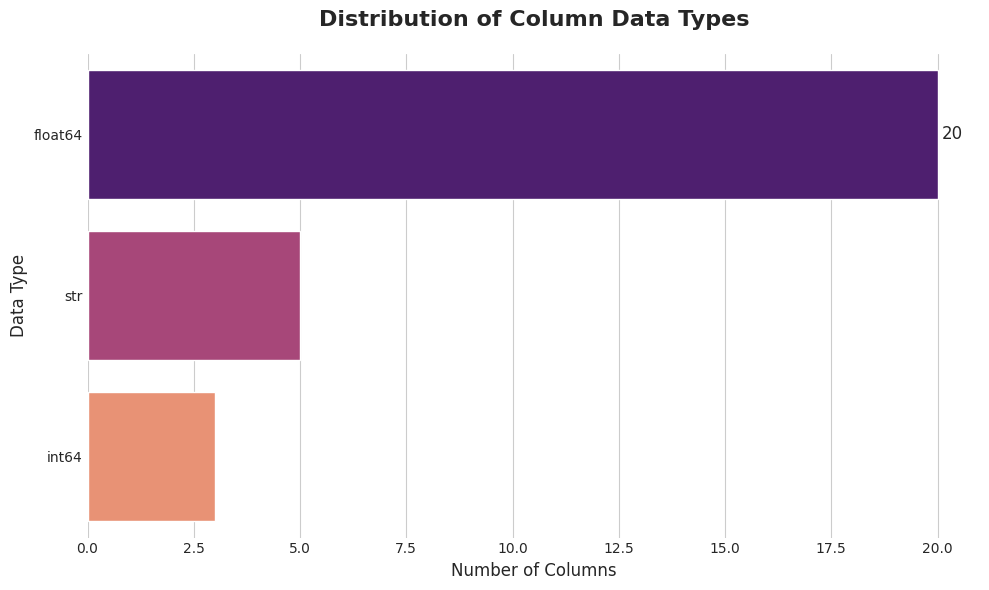

In [5]:

data_types = train_df.dtypes.value_counts().reset_index()
data_types.columns = ['Dtype', 'Count']

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=data_types, 
    x='Count', 
    y='Dtype', 
    palette='magma',
    hue='Dtype',
    legend=False
)

ax.bar_label(ax.containers[0], padding=3, fontsize=12)

plt.title('Distribution of Column Data Types', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Columns', fontsize=12)
plt.ylabel('Data Type', fontsize=12)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [6]:

full_years = set([2018, 2019, 2020, 2021])

company_years = train_df.groupby("company_id")["fiscal_year"].apply(set)
incomplete = company_years[company_years.apply(len) < 4]

print(f"Companies with incomplete history: {len(incomplete)} / {train_df['company_id'].nunique()}")

summary = pd.DataFrame({
    "years_present": incomplete,
    "years_missing": incomplete.apply(lambda y: sorted(full_years - y)),
    "n_years": incomplete.apply(len)
})

print("\nMissing year patterns:")
print(summary["years_missing"].value_counts())


Companies with incomplete history: 104 / 2999

Missing year patterns:
years_missing
[2018]                37
[2021]                23
[2020, 2021]          23
[2019, 2020, 2021]    20
[2018, 2021]           1
Name: count, dtype: int64


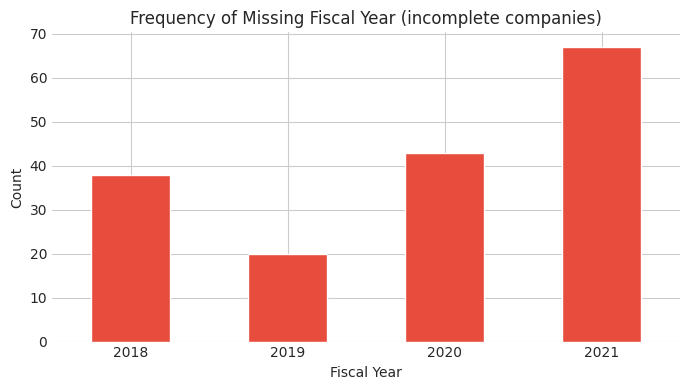

In [7]:
# Visualise: which fiscal year is most often absent
from itertools import chain

all_missing = list(chain.from_iterable(summary["years_missing"]))
missing_counts = pd.Series(all_missing).value_counts().sort_index()

missing_counts.plot(kind="bar", color="#e74c3c", edgecolor="white", figsize=(7, 4))
plt.title("Frequency of Missing Fiscal Year (incomplete companies)")
plt.xlabel("Fiscal Year"); plt.ylabel("Count")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


In [8]:
# Are incomplete companies concentrated in a specific class or sector?
incomplete_ids = incomplete.index
incomplete_df = train_df[train_df["company_id"].isin(incomplete_ids)]

print("Class distribution — incomplete companies:")
print(incomplete_df.drop_duplicates("company_id")[TARGET].value_counts(normalize=True).round(3))

print("\nTop sectors — incomplete companies:")
print(incomplete_df.drop_duplicates("company_id")["ateco_sector"].value_counts().head(10))


Class distribution — incomplete companies:
financial_health_class
B    0.433
D    0.288
C    0.221
A    0.058
Name: proportion, dtype: float64

Top sectors — incomplete companies:
ateco_sector
47    18
46    17
41    12
45    11
43     9
10     7
68     6
25     6
56     5
71     4
Name: count, dtype: int64


In [9]:
# Check for year gaps within a company's history (e.g. 2018, 2020 — missing 2019)
def find_gaps(years):
    years = sorted(years)
    gaps = []
    for i in range(len(years) - 1):
        expected = years[i] + 1
        actual = years[i + 1]
        if actual != expected:
            gaps.append((years[i], actual))  # (last seen, next seen)
    return gaps

company_gaps = company_years.apply(find_gaps)
companies_with_gaps = company_gaps[company_gaps.apply(len) > 0]

print(f"Companies with year gaps: {len(companies_with_gaps)} / {train_df['company_id'].nunique()}")
print("\nGap patterns (from_year → to_year):")
print(companies_with_gaps.explode().value_counts())


Companies with year gaps: 0 / 2999

Gap patterns (from_year → to_year):
Series([], Name: count, dtype: int64)


In [10]:
# For each incomplete company, check if missing years are at the start or end
def missing_position(years):
    years = sorted(years)
    missing = sorted(full_years - set(years))
    positions = []
    for y in missing:
        if y < years[0]:
            positions.append(f"start, {years[0]}")   # missing early years → entered dataset late
        elif y > years[-1]:
            positions.append(f"end, {years[-1]}")     # missing late years → exited dataset early
        else:
            positions.append("middle")  # impossible given no gaps, but safety check
    return positions

summary["missing_position"] = summary["years_present"].apply(missing_position)
print(summary["missing_position"].explode().value_counts())


missing_position
end, 2018      60
end, 2019      46
start, 2019    38
end, 2020      24
Name: count, dtype: int64


In [11]:
# Do companies missing 2021 skew toward D?
missing_2021 = summary[summary["years_missing"].apply(lambda x: 2021 in x)].index
print("Class dist — missing 2021 (early exits):")
print(train_df[train_df["company_id"].isin(missing_2021)][TARGET].value_counts(normalize=True).round(3))

# Compare to full dataset
print("\nClass dist — full dataset:")
print(train_df[TARGET].value_counts(normalize=True).round(3))


Class dist — missing 2021 (early exits):
financial_health_class
D    0.650
C    0.190
B    0.131
A    0.029
Name: proportion, dtype: float64

Class dist — full dataset:
financial_health_class
B    0.593
C    0.232
D    0.089
A    0.085
Name: proportion, dtype: float64



- Scalers and imputers must be **fit on train only**, then applied to test
- Lag features must use **only past data** (year `t-1` → year `t`)
- Never use features from year `t+1` to predict class at year `t`

---

### 🔍 Finding: Incomplete Companies are Not Missing at Random

**104 companies have fewer than 4 years** in the training set:

| Pattern | Count | Interpretation |
|---|---|---|
| Missing at **end** (early exits) | 130 observations | Company stopped filing — likely distress |
| Missing at **start** (late entrants) | 38 observations | Young company, entered after 2018 |

**Early exits are strongly associated with class D:**

| Class | Early Exits | Full Dataset |
|-------|-------------|--------------|
| A     | 2.9%        | 8.5%         |
| B     | 13.1%       | 59.3%        |
| C     | 19.0%       | 23.2%        |
| D     | **65.0%**   | **8.9%**     |

65% of companies that disappeared before 2021 were class D — vs only 8.9% in the full dataset.  
This is **informative missingness**, not random. These companies stopped filing due to severe financial distress.

> **Survivorship bias**: companies present in the test set (2022–2023) are survivors by definition.  
> The model may underestimate D risk for companies that will exit mid-period. This is a known limitation.

---

### Time Dimension as an Asset: Lag Features

Since most companies have 4 consecutive years of contiguous data, we can engineer **trend features**  
that capture whether a company's financial health is improving or deteriorating.

A company with ROE dropping from `0.4 → 0.1` is riskier than one stable at `0.15`,  
even though the current value is higher. Raw snapshots miss this signal.

**Features to engineer (computed at year `t` using year `t-1`)**:

| Feature | Formula | Signal |
|---|---|---|
| `roe_prev` | `roe` at `t-1` | Profitability baseline |
| `roi_prev` | `roi` at `t-1` | Efficiency baseline |
| `current_ratio_prev` | `current_ratio` at `t-1` | Liquidity baseline |
| `roe_yoy` | `roe_t - roe_{t-1}` | Profitability trend |
| `roi_yoy` | `roi_t - roi_{t-1}` | Efficiency trend |
| `leverage_trend` | `leverage_t - leverage_{t-1}` | Increasing debt signal |
| `equity_growth` | `(equity_t - equity_{t-1}) / abs(equity_{t-1})` | Capital erosion signal |
| `is_last_observation` | 1 if final row for company | Exit/distress signal |
| `n_years_in_panel` | count of years in dataset | Short history = higher risk |

> Late entrants (38 companies missing 2018) will have `NaN` lag features on their first row → imputed with median during preprocessing.  
> `is_last_observation` and `n_years_in_panel` must be computed **before** the train/test split to avoid leakage.

---

### Cross-Validation Strategy

Standard k-fold CV is **not valid** here because it would leak future data into training.  
Use **time-based expanding window CV** on the training set:

| Fold | Train | Validation |
|---|---|---|
| 1 | 2018 | 2019 |
| 2 | 2018–2019 | 2020 |
| 3 | 2018–2020 | 2021 ← most important |

Use `sklearn.model_selection.TimeSeriesSplit` or build manually on `fiscal_year`.  
**Never shuffle** when splitting.

---

### Full Modeling Flow
Sort by company_id + fiscal_year

Compute panel features: is_last_observation, n_years_in_panel

Engineer lag features (shift within each company group)

Temporal train/val split for CV (no shuffle)

Fit scaler + imputer on train only → transform val and test

Train classifier on all train years (2018–2021)

Predict on test set (2022–2023)

Evaluate: Weighted F1 (primary), Confusion Matrix, Per-class Precision/Recall

## 2. Target Variable Analysis
- Class counts and percentages (A/B/C/D)
- Class distribution per `fiscal_year` — detect COVID drift in 2020–2021
- Class distribution by `ateco_sector`, `legal_form`, `region`

In [12]:

counts = train_df[TARGET].value_counts().reindex(CLASSES)
pcts   = train_df[TARGET].value_counts(normalize=True).reindex(CLASSES) * 100

print(pd.concat([counts, pcts.round(2)], axis=1, keys=["count", "%"]))


                        count      %
financial_health_class              
A                        1003   8.48
B                        7017  59.33
C                        2750  23.25
D                        1058   8.94


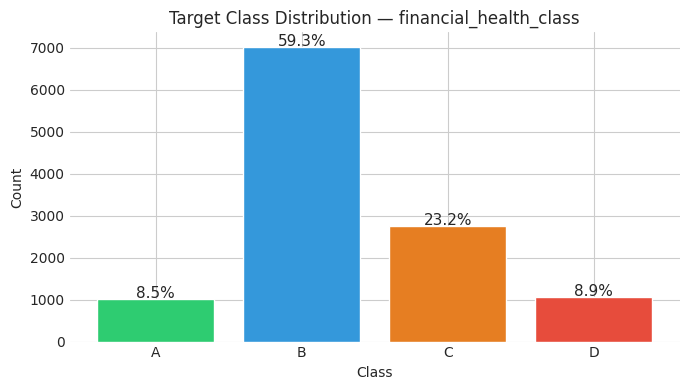

In [13]:

fig, ax = plt.subplots(figsize=(7, 4))
palette = {"A": "#2ecc71", "B": "#3498db", "C": "#e67e22", "D": "#e74c3c"}
bars = ax.bar(CLASSES, counts, color=[palette[c] for c in CLASSES], edgecolor="white")
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", fontsize=11)
ax.set_title("Target Class Distribution — financial_health_class")
ax.set_xlabel("Class"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


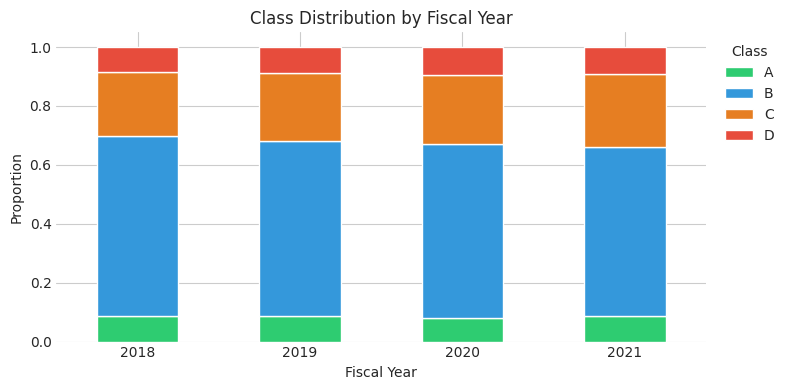

financial_health_class    A     B    C    D
fiscal_year                                
2018                    254  1815  640  252
2019                    260  1766  691  262
2020                    239  1745  695  277
2021                    250  1691  724  267


In [14]:
# 2.3 Class distribution per fiscal year — detect COVID drift
yearly = pd.crosstab(train_df["fiscal_year"], train_df[TARGET], normalize="index")[CLASSES]

yearly.plot(kind="bar", stacked=True, figsize=(8, 4),
            color=[palette[c] for c in CLASSES], edgecolor="white")
plt.title("Class Distribution by Fiscal Year")
plt.ylabel("Proportion"); plt.xlabel("Fiscal Year")
plt.xticks(rotation=0); plt.legend(title="Class", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

# Raw numbers per year
print(pd.crosstab(train_df["fiscal_year"], train_df[TARGET]))


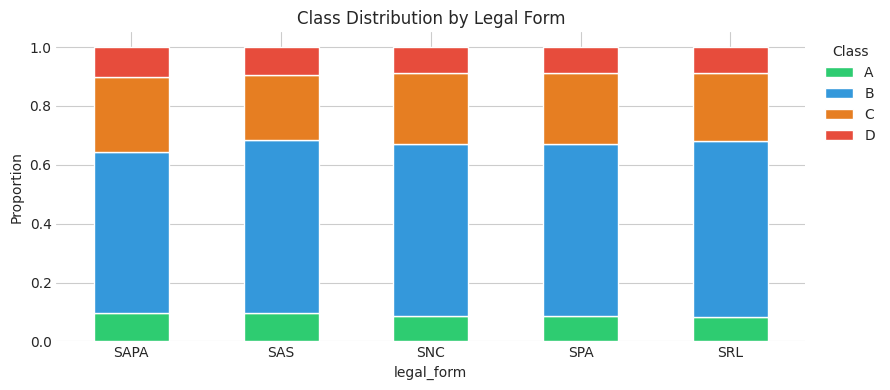

financial_health_class,A,B,C,D
legal_form,,,,
SAPA,0.094972,0.547486,0.256983,0.100559
SAS,0.096452,0.586475,0.220621,0.096452
SNC,0.087948,0.583062,0.241042,0.087948
SPA,0.086624,0.584713,0.239490,0.089172
SRL,0.082798,0.597221,0.231344,0.088637


In [15]:

legal = pd.crosstab(train_df["legal_form"], train_df[TARGET], normalize="index")[CLASSES]
legal.plot(kind="bar", stacked=True, figsize=(9, 4),
           color=[palette[c] for c in CLASSES], edgecolor="white")
plt.title("Class Distribution by Legal Form")
plt.ylabel("Proportion"); plt.xticks(rotation=0)
plt.legend(title="Class", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

legal

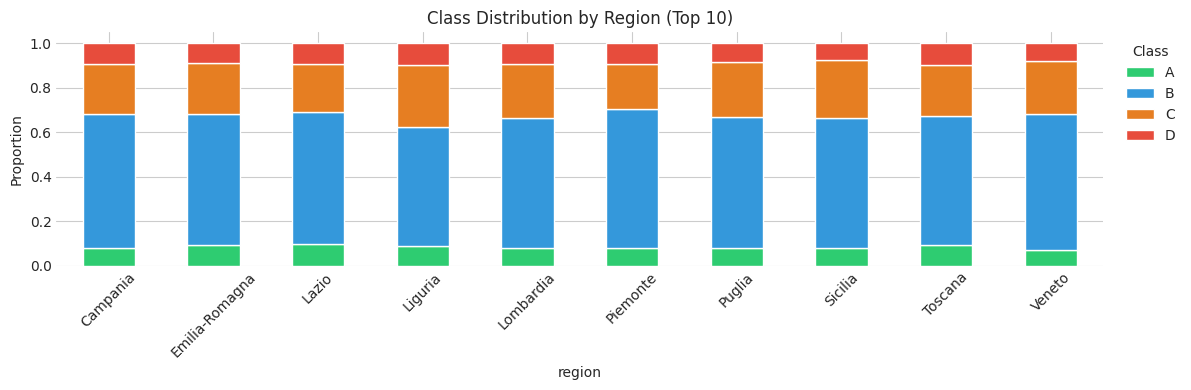

financial_health_class,A,B,C,D
region,,,,
Campania,0.078346,0.606094,0.224157,0.091404
Emilia-Romagna,0.093593,0.588913,0.228942,0.088553
Lazio,0.096123,0.597451,0.214551,0.091875
Liguria,0.087282,0.538653,0.276808,0.097257
Lombardia,0.078696,0.586645,0.241653,0.093005
Piemonte,0.080402,0.623116,0.202261,0.094221
Puglia,0.077406,0.592050,0.246862,0.083682
Sicilia,0.079065,0.584633,0.260579,0.075724
Toscana,0.092926,0.581137,0.227462,0.098474


In [16]:
# 2.5 Class distribution by region (top 10 regions by count)
top_regions = train_df["region"].value_counts().head(10).index
region_df = train_df[train_df["region"].isin(top_regions)]

region = pd.crosstab(region_df["region"], region_df[TARGET], normalize="index")[CLASSES]
region.plot(kind="bar", stacked=True, figsize=(12, 4),
            color=[palette[c] for c in CLASSES], edgecolor="white")
plt.title("Class Distribution by Region (Top 10)")
plt.ylabel("Proportion"); plt.xticks(rotation=45)
plt.legend(title="Class", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

region

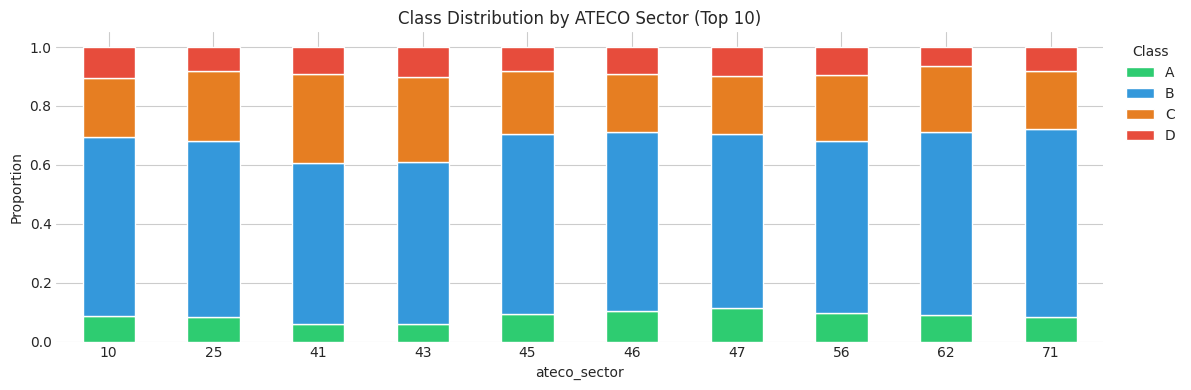

financial_health_class,A,B,C,D
ateco_sector,,,,
10,0.085595,0.608559,0.200418,0.105428
25,0.084932,0.597260,0.236530,0.081279
41,0.059386,0.548123,0.300341,0.092150
43,0.061396,0.549201,0.287637,0.101766
45,0.095166,0.610272,0.212991,0.081571
46,0.102488,0.608412,0.196682,0.092417
47,0.114017,0.590879,0.196512,0.098592
56,0.098143,0.582228,0.225464,0.094164
62,0.091579,0.620000,0.224211,0.064211


In [17]:
# 2.6 Class distribution by ateco_sector (top 10 sectors by count)
top_sectors = train_df["ateco_sector"].value_counts().head(10).index
sector_df = train_df[train_df["ateco_sector"].isin(top_sectors)]

sector = pd.crosstab(sector_df["ateco_sector"], sector_df[TARGET], normalize="index")[CLASSES]
sector.plot(kind="bar", stacked=True, figsize=(12, 4),
            color=[palette[c] for c in CLASSES], edgecolor="white")
plt.title("Class Distribution by ATECO Sector (Top 10)")
plt.ylabel("Proportion"); plt.xticks(rotation=0)
plt.legend(title="Class", bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

sector

In [76]:
train_df.columns

Index(['company_id', 'fiscal_year', 'province', 'region', 'ateco_sector',
       'legal_form', 'years_in_business', 'total_fixed_assets',
       'current_assets', 'total_assets', 'shareholders_equity', 'total_debt',
       'short_term_debt', 'long_term_debt', 'production_value',
       'production_costs', 'operating_income', 'financial_income',
       'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage',
       'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin',
       'financial_health_class'],
      dtype='str')

In [81]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

Dataset shape: (11828, 29)
Sectors: 8
Global class dist (%):
 financial_health_class
B    59.3
C    23.2
D     8.9
A     8.5
Name: proportion, dtype: float64

CHI2: chi2=190.93, p=2.18e-29, dof=21
Significant

D-class % by sector (sorted):
sector_name
Construction                                      9.6
Accommodation and Food Service                    9.4
Administrative and Support Services               9.4
Manufacturing                                     9.3
Wholesale and Retail Trade                        9.3
Professional, Scientific, Technical Activities    8.2
Information and Communication                     6.4
Real Estate Activities                            5.1
Name: D, dtype: float64

Info Gain: 0.0415 bits (0=zero power, >0.01=moderate)
Mutual Info score: 0.0096 (compare to other features)

D-class stats (%): mean=8.3, std=1.7, range=4.5

✅ MODERATE discriminative power: Use for relative features (e.g., sector-medians)
D std=1.7%, InfoGain=0.0415 → Standalone OK


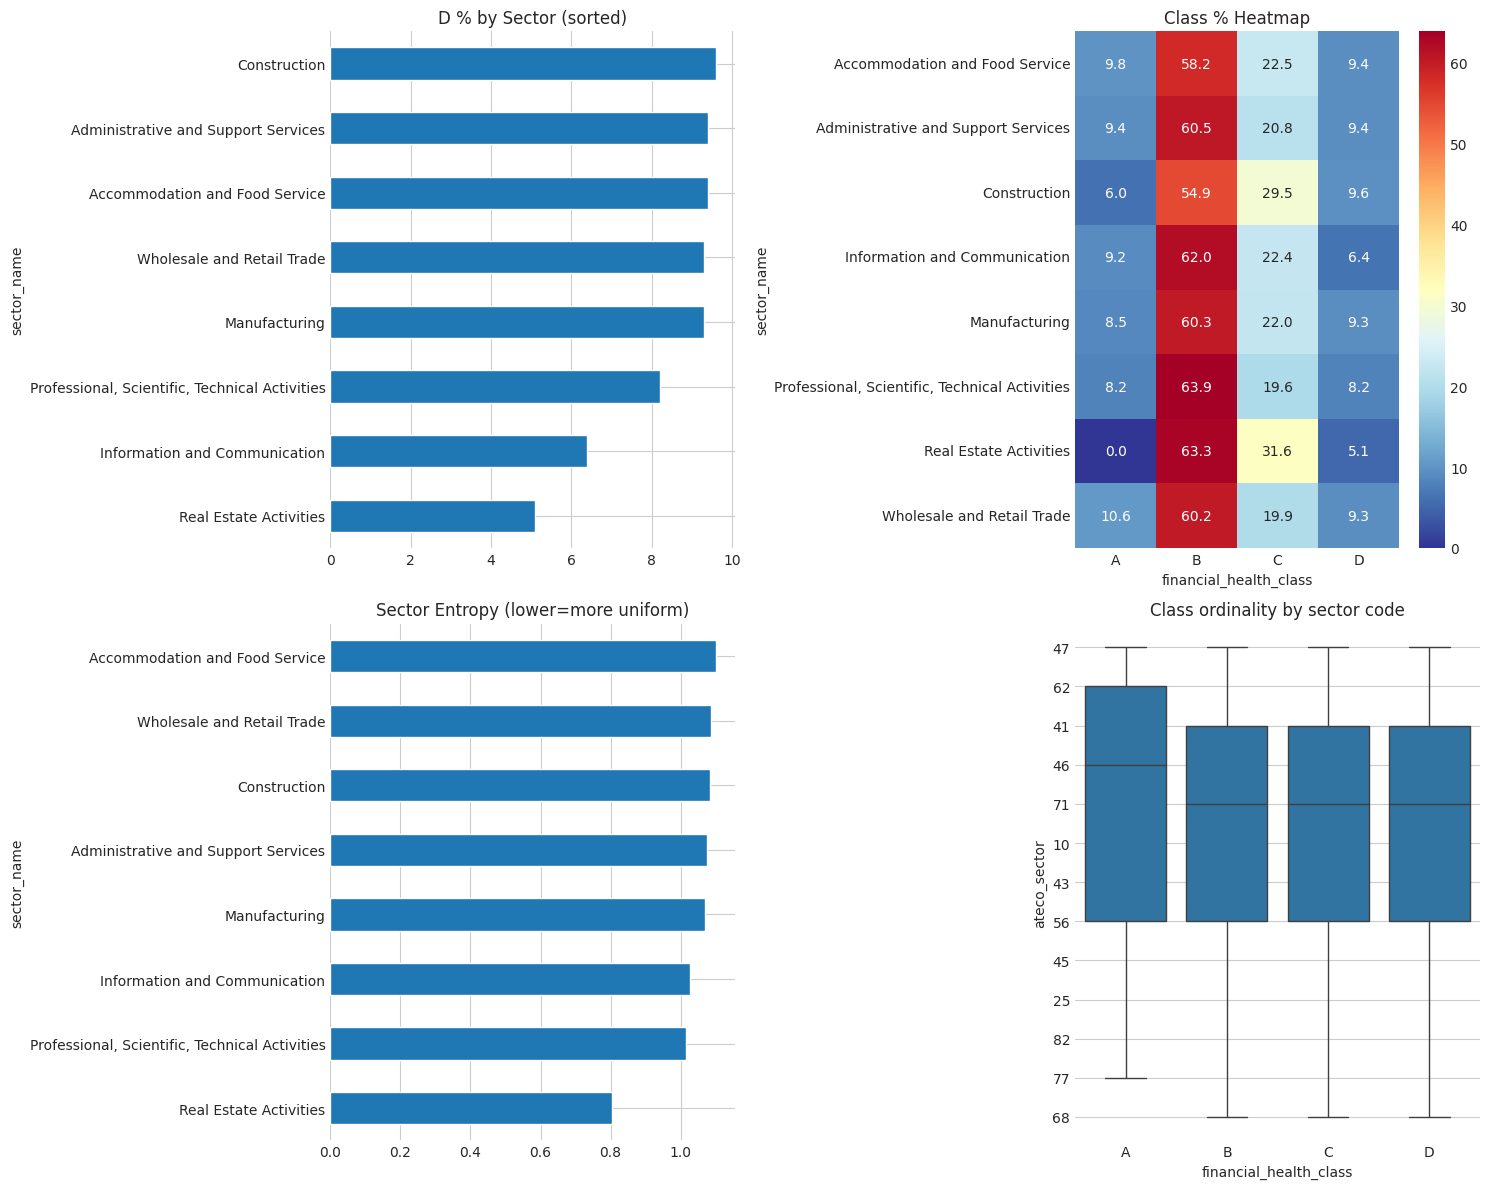

In [ ]:
ateco_sectors = {
    (1, 3): "Agriculture, Forestry, Fishing",
    (5, 9): "Mining and Quarrying",
    (10, 33): "Manufacturing",
    (35, 35): "Electricity, Gas, Steam",
    (36, 39): "Water Supply, Sewerage, Waste",
    (41, 43): "Construction",
    (45, 47): "Wholesale and Retail Trade",
    (49, 53): "Transportation and Storage",
    (55, 56): "Accommodation and Food Service",
    (58, 63): "Information and Communication",
    (64, 66): "Financial and Insurance Activities",
    (68, 68): "Real Estate Activities",
    (69, 75): "Professional, Scientific, Technical Activities",
    (77, 82): "Administrative and Support Services",
    (84, 84): "Public Administration",
    (85, 85): "Education",
    (86, 88): "Human Health and Social Work",
    (90, 93): "Arts, Entertainment, Recreation",
    (94, 96): "Other Service Activities"
}

def get_sector_name(code):
    """Map ATECO code to sector name."""
    code_int = int(code)
    for (min_code, max_code), name in ateco_sectors.items():
        if min_code <= code_int <= max_code:
            return name
    return "Unknown"


# Prep data (fix your column names)
train_df['ateco_sector'] = train_df['ateco_sector'].astype(str).str.zfill(2)
train_df['sector_name'] = train_df['ateco_sector'].apply(get_sector_name)
train_df['financial_health_class'] = train_df['financial_health_class'].astype('category')

print("Dataset shape:", train_df.shape)
print("Sectors:", train_df['sector_name'].nunique())
print("Global class dist (%):\n", train_df['financial_health_class'].value_counts(normalize=True).round(3)*100)

# 1. CHI-SQUARE TEST (association strength)
contingency = pd.crosstab(train_df['sector_name'], train_df['financial_health_class'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nCHI2: chi2={chi2:.2f}, p={p_value:.2e}, dof={dof}")
print("Significant" if p_value < 0.05 else "NOT significant")

# 2. CROSS-TAB % (visual variation)
cross = pd.crosstab(train_df['sector_name'], train_df['financial_health_class'], 
                    normalize='index') * 100
cross = cross.round(1)
print("\nD-class % by sector (sorted):")
print(cross['D'].sort_values(ascending=False))

# Save full cross
cross.to_csv('ateco_class_crosstab.csv')

# 3. ENTROPY / INFO GAIN (discriminative power)
def entropy(probs):
    probs = probs[probs > 0] / 100
    return -np.sum(probs * np.log(probs))

global_probs = train_df['financial_health_class'].value_counts(normalize=True).sort_index()
global_entropy = -np.sum(global_probs * np.log(global_probs + 1e-10))

sector_entropies = cross.apply(entropy, axis=1)
info_gain = global_entropy - sector_entropies.mean()
print(f"\nInfo Gain: {info_gain:.4f} bits (0=zero power, >0.01=moderate)")

# 4. MUTUAL INFO (ML feature importance proxy)
le_sector = LabelEncoder()
X = le_sector.fit_transform(train_df['sector_name'])
y = LabelEncoder().fit_transform(train_df['financial_health_class'])
mi_score = mutual_info_classif(X.reshape(-1,1), y, discrete_features=True).max()
print(f"Mutual Info score: {mi_score:.4f} (compare to other features)")

# 5. D-class variation (practical range)
d_stats = cross['D'].agg(['mean', 'std', 'min', 'max']).round(1)
print(f"\nD-class stats (%): mean={d_stats['mean']}, std={d_stats['std']}, range={d_stats['max']-d_stats['min']}")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# D bar
cross['D'].sort_values().plot(kind='barh', ax=axes[0,0])
axes[0,0].set_title('D % by Sector (sorted)')

# Heatmap
sns.heatmap(cross, annot=True, fmt='.1f', cmap='RdYlBu_r', ax=axes[0,1])
axes[0,1].set_title('Class % Heatmap')

# Sector entropies
sector_entropies.sort_values().plot(kind='barh', ax=axes[1,0])
axes[1,0].set_title('Sector Entropy (lower=more uniform)')

# Boxplot class dist per sector
sns.boxplot(data=train_df, x='financial_health_class', y='ateco_sector', ax=axes[1,1])
axes[1,1].set_title('Class ordinality by sector code')

plt.tight_layout()
plt.savefig('ateco_power_assert.png', dpi=150, bbox_inches='tight')

# CONCLUSION PRINT
print("\n" + "="*50)
if p_value < 0.05 and d_stats['std'] > 1:
    print("MODERATE discriminative power: Use for relative features (e.g., sector-medians)")
elif p_value < 0.05:
    print("WEAK power: Minor variations, low MI expected")
else:
    print("NO discriminative power: Drop or ignore")
print(f"D std={d_stats['std']}%, InfoGain={info_gain:.4f} → {'Relative feats needed' if info_gain < 0.01 else 'Standalone OK'}")

## Section 2 — Target Variable Analysis: Findings

### 2.1 Class Imbalance

The dataset is **moderately imbalanced**:

| Class | Count | % |
|-------|-------|---|
| A — Excellent | 1,003 | 8.5% |
| B — Good | 7,017 | 59.3% |
| C — Moderate risk | 2,750 | 23.3% |
| D — High risk | 1,058 | 8.9% |

B dominates the dataset. A and D are the minority classes and the hardest to classify correctly.
This means **accuracy is a misleading metric** — a model predicting B for everything would reach 59% accuracy.
→ Use **Weighted F1** as primary metric. Apply `class_weight="balanced"` in all models.

---

### 2.2 No COVID Drift Detected

Class distribution is **remarkably stable** across all 4 years:

| Year | A | B | C | D |
|------|---|---|---|---|
| 2018 | 254 | 1815 | 640 | 252 |
| 2019 | 260 | 1766 | 691 | 262 |
| 2020 | 239 | 1745 | 695 | 277 |
| 2021 | 250 | 1691 | 724 | 267 |

No significant spike in D during 2020–2021 despite COVID-19.
C shows a mild upward trend (+13% from 2018 to 2021) but no structural shift.
→ `fiscal_year` is **not a strong standalone predictor** — but keep it as a feature
to capture any subtle macro trend the model can learn.

---

### 2.3 Legal Form has Minimal Predictive Power

All legal forms (SRL, SPA, SAS, SNC, SAPA) show nearly identical class distributions,
all within ±2% of the global baseline.
→ `legal_form` is a **weak feature**. Encode it but don't expect high importance.

---

### 2.4 Region has Minimal Predictive Power

Regional differences are small. Notable exceptions:
- **Liguria** has the highest C rate (27.7%) and lowest B rate (53.9%) — slightly riskier
- **Piemonte** has the highest B rate (62.3%) — slightly healthier
- **Veneto** has the lowest A rate (7.0%)

Differences are marginal (~5% range across regions).
→ `region` is a **weak feature**. Consider grouping into macro-areas (Nord/Centro/Sud)
to reduce cardinality without losing the small signal.

---

### 2.5 ATECO Sector has Moderate Predictive Power

More meaningful variation than region or legal form:
- **Construction (41, 43)** — highest C rates (30%, 28.8%) and lowest A rates (~6%) →
  capital-intensive sectors with thin margins and high debt
- **Wholesale trade (46, 47)** — highest A rates (10.2%, 11.4%) → healthier cash flow
  businesses
- **IT services (62)** — lowest D rate (6.4%) → knowledge-based sectors are more resilient
- **Food manufacturing (10)** — highest D rate (10.5%)

→ `ateco_sector` is a **meaningful feature**. Keep at full granularity.
Also engineer **sector-relative ratios** (e.g., `roe - sector_median_roe`) to
capture how a company performs vs its peers.

---

### Preprocessing Decisions from Section 2

1. **Never use accuracy** — always Weighted F1
2. **Apply `class_weight="balanced"`** in all classifiers
3. **Keep `fiscal_year`** as a feature (mild macro signal)
4. **Encode `legal_form` and `region`** but expect low importance
5. **Keep `ateco_sector` at full granularity** — engineer sector-relative ratio features
6. **Consider macro-region grouping** (Nord/Centro/Sud) as an additional feature


### 3. Missing Values
- Missing count and % per column
- Structural vs random: `roe`/`leverage` missing when equity = 0
- `province` missingness — correlated with class?
- Missingness heatmap by `fiscal_year`

In [18]:
# 3.1 Missing count and % per column
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(train_df) * 100).round(2)
print(pd.concat([missing, pct], axis=1, keys=["count", "%"]))


          count     %
province    919  7.77
roe          45  0.38
leverage     45  0.38


In [19]:
# 3.2 Is roe/leverage missingness structural (equity = 0)?
mask_roe = train_df["roe"].isnull()
print(f"ROE null rows: {mask_roe.sum()}")
print(f"Of which equity = 0: {(train_df.loc[mask_roe, 'shareholders_equity'] == 0).sum()}")
print(f"Of which equity < 0: {(train_df.loc[mask_roe, 'shareholders_equity'] < 0).sum()}")
print(f"\nLeverage null rows: {train_df['leverage'].isnull().sum()}")
print(f"Same rows as ROE null: {(train_df['roe'].isnull() == train_df['leverage'].isnull()).all()}")


ROE null rows: 45
Of which equity = 0: 0
Of which equity < 0: 45

Leverage null rows: 45
Same rows as ROE null: True


In [20]:
# 3.3 Class distribution where roe/leverage is null
print("Class dist — where ROE is null:")
print(train_df[mask_roe][TARGET].value_counts(normalize=True).round(3))

print("\nClass dist — full dataset:")
print(train_df[TARGET].value_counts(normalize=True).round(3))


Class dist — where ROE is null:
financial_health_class
D    1.0
Name: proportion, dtype: float64

Class dist — full dataset:
financial_health_class
B    0.593
C    0.232
D    0.089
A    0.085
Name: proportion, dtype: float64


In [61]:
train_df.columns

Index(['company_id', 'fiscal_year', 'province', 'region', 'ateco_sector',
       'legal_form', 'years_in_business', 'total_fixed_assets',
       'current_assets', 'total_assets', 'shareholders_equity', 'total_debt',
       'short_term_debt', 'long_term_debt', 'production_value',
       'production_costs', 'operating_income', 'financial_income',
       'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage',
       'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin',
       'financial_health_class'],
      dtype='str')

In [72]:
train_df['legal_form'].value_counts()

legal_form
SRL     8563
SPA     1570
SAS      902
SNC      614
SAPA     179
Name: count, dtype: int64

In [69]:
null_roe = train_df[train_df['roe'].isnull()][['fiscal_year','legal_form','total_assets', 'shareholders_equity', 'total_debt','financial_health_class']]
null_roe.describe().T

,count,mean,std,min,25%,50%,75%,max
fiscal_year,45.0,2.019444e+03,1.119163e+00,2.018000e+03,2.018000e+03,2.019000e+03,2.020000e+03,2.021000e+03
total_assets,45.0,1.952314e+09,4.106301e+09,3.666777e+07,2.351654e+08,4.967457e+08,1.401854e+09,2.253141e+10
shareholders_equity,45.0,-2.121737e+08,5.473418e+08,-3.330561e+09,-1.049190e+08,-5.179643e+07,-1.106439e+07,-1.704464e+05
total_debt,45.0,2.164488e+09,4.629608e+09,3.683821e+07,2.646082e+08,5.922573e+08,1.506773e+09,2.586197e+10


In [ ]:
need_to_recapitilized = train_df[(train_df['legal_form'] == 'SRL') & train_df['share']]

In [21]:
# How prevalent is negative equity across classes?
train_df["negative_equity"] = (train_df["shareholders_equity"] < 0).astype(int)

print("Negative equity rate by class:")
print(train_df.groupby(TARGET)["negative_equity"].mean().round(3) * 100)

print("\nNegative equity count by class:")
print(train_df.groupby(TARGET)["negative_equity"].sum())


Negative equity rate by class:
financial_health_class
A    0.0
B    0.0
C    0.0
D    4.3
Name: negative_equity, dtype: float64

Negative equity count by class:
financial_health_class
A     0
B     0
C     0
D    45
Name: negative_equity, dtype: int64


In [22]:
# Of all class D rows, what % have negative equity?
d_rows = train_df[train_df[TARGET] == "D"]
print(f"Class D rows with negative equity: {d_rows['negative_equity'].sum()} / {len(d_rows)}")
print(f"That is {d_rows['negative_equity'].mean()*100:.1f}% of all D rows")

train_df.drop(columns="negative_equity", inplace=True)


Class D rows with negative equity: 45 / 1058
That is 4.3% of all D rows


In [23]:
# 3.4 Province missingness — correlated with class?
train_df["province_missing"] = train_df["province"].isnull().astype(int)

print("Class dist — province missing:")
print(train_df[train_df["province_missing"] == 1][TARGET].value_counts(normalize=True).round(3))

print("\nProvince missing rate % by class:")
print(f"{train_df.groupby(TARGET)["province_missing"].mean().round(3)*100}")

train_df.drop(columns="province_missing", inplace=True)


Class dist — province missing:
financial_health_class
B    0.606
C    0.224
D    0.091
A    0.078
Name: proportion, dtype: float64

Province missing rate % by class:
financial_health_class
A    7.2
B    7.9
C    7.5
D    7.9
Name: province_missing, dtype: float64


In [24]:
# 3.5 Missingness by fiscal year
missing_by_year = train_df.groupby("fiscal_year")[["roe", "leverage", "province"]].apply(
    lambda x: x.isnull().sum()
)
print(missing_by_year)


             roe  leverage  province
fiscal_year                         
2018          12        12       228
2019          11        11       232
2020          12        12       230
2021          10        10       229



## Section 3 — Missing Values: Findings

### 3.1 Overview

Only 3 columns have missing values:

| Column | Missing | % | Type |
|--------|---------|---|------|
| `province` | 919 | 7.77% | Random (MCAR) |
| `roe` | 45 | 0.38% | Structural |
| `leverage` | 45 | 0.38% | Structural |

The dataset is **exceptionally clean** — no balance sheet or income statement
items are missing.

---

### 3.2 ROE & Leverage — Structural Missingness (100% signal for class D)

All 45 null `roe` and `leverage` rows belong to the **exact same observations**
and all have **negative shareholders equity**.

When equity is negative:
- `roe = net_profit / equity` → mathematically valid but financially meaningless
- `leverage = total_debt / equity` → negative leverage is uninterpretable

The dataset correctly marks these as `NaN` rather than showing a misleading value.

**Critical finding: 100% of rows where ROE is null are class D.**

This means null `roe`/`leverage` is not a data quality issue —
it is the **strongest possible signal of distress** in the entire dataset.

→ **Do NOT impute these with median.** Instead:
1. Create `roe_is_null` binary feature (= 1 when equity is negative)
2. Impute the raw value with an **extreme negative sentinel** (e.g. `-99`)
   to preserve the distress signal for tree-based models
3. For linear models, impute with a value well below the 1st percentile

---

### 3.3 Negative Equity Deep Dive

Negative equity is **exclusive to class D** — zero cases in A, B, or C.
However it only covers **4.3% of all D rows** (45 / 1,058).

| Finding | Implication |
|---|---|
| Negative equity never appears in A/B/C | `roe_is_null` is a **perfect precision** signal — when it fires, it is always D |
| Only 4.3% of D rows have negative equity | `roe_is_null` has **very low recall** — catches only a small fraction of distressed companies |

This means negative equity is a **late-stage distress indicator** — the company
is already deep in trouble. The model must detect D much earlier using
deterioration signals from other features (leverage trend, ROI decline,
liquidity squeeze) before equity turns negative.

→ `roe_is_null` is a **high-precision, low-recall** feature. Keep it — it will
likely become a top split in tree-based models for class D. The bulk of D
detection must come from financial ratio trends.

---

### 3.4 Province — Missing Completely at Random (MCAR)

Province missingness rate is **uniform across all classes** (~7.2–7.9%):

| Class | Province missing % |
|-------|--------------------|
| A | 7.2% |
| B | 7.9% |
| C | 7.5% |
| D | 7.9% |

No correlation with class, sector, or fiscal year (stable ~229 missing per year).
This is **Missing Completely at Random (MCAR)** — likely companies that registered
without a province code in the source database.

→ **Impute with a new category `"UNKNOWN"`** — do not drop rows or use
mode imputation, as province is a categorical with 107 levels and the
missing pattern carries no financial signal.

---

### 3.5 Missingness is Stable Across Years

No year concentration — ~11–12 null `roe`/`leverage` and ~229 null `province`
per year consistently. No COVID-related reporting gaps detected.

---

### Preprocessing Decisions from Section 3

| Column | Treatment | Rationale |
|--------|-----------|-----------|
| `roe`, `leverage` | Add `roe_is_null` binary flag → impute with sentinel `-99` | Perfect D signal, must preserve |
| `province` | Impute with `"UNKNOWN"` category | MCAR, no financial signal |
| All other columns | No imputation needed | Dataset is complete |

### 4. Descriptive Statistics
- Summary stats for all numerical columns
- Log-scale histograms for balance sheet items (heavy right skew expected)
- Check impossible values: negative revenue, `debt_to_assets > 1`


In [25]:
# 4.1 Summary statistics for all numerical columns
train_df[NUMERICAL_COLS].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
total_fixed_assets,11828.0,1.029206e+09,6.120958e+09,1.267167e+06,7.319803e+07,1.905995e+08,5.398741e+08,2.548712e+11
current_assets,11828.0,1.438435e+09,6.873106e+09,1.278800e+06,1.244471e+08,3.125597e+08,8.387197e+08,2.512549e+11
total_assets,11828.0,2.467641e+09,1.248305e+10,2.545968e+06,2.087793e+08,5.212379e+08,1.394478e+09,5.061262e+11
shareholders_equity,11828.0,9.163141e+08,5.023564e+09,-3.330561e+09,7.070428e+07,1.815958e+08,5.022747e+08,1.956145e+11
total_debt,11828.0,1.551327e+09,7.724478e+09,1.839791e+06,1.294646e+08,3.264152e+08,8.795087e+08,3.105116e+11
short_term_debt,11828.0,8.534656e+08,4.360360e+09,8.985461e+05,6.925617e+07,1.744802e+08,4.777298e+08,1.699685e+11
long_term_debt,11828.0,6.978617e+08,3.493369e+09,9.412449e+05,5.666362e+07,1.462585e+08,3.960070e+08,1.405431e+11
production_value,11828.0,3.969063e+09,1.896096e+10,2.329670e+06,2.984883e+08,8.040019e+08,2.241163e+09,6.044366e+11
production_costs,11828.0,3.680129e+09,1.757911e+10,1.580518e+06,2.731290e+08,7.459428e+08,2.075266e+09,5.736470e+11
operating_income,11828.0,2.889337e+08,1.574126e+09,-2.688184e+09,1.698626e+07,5.128590e+07,1.538062e+08,5.621927e+10


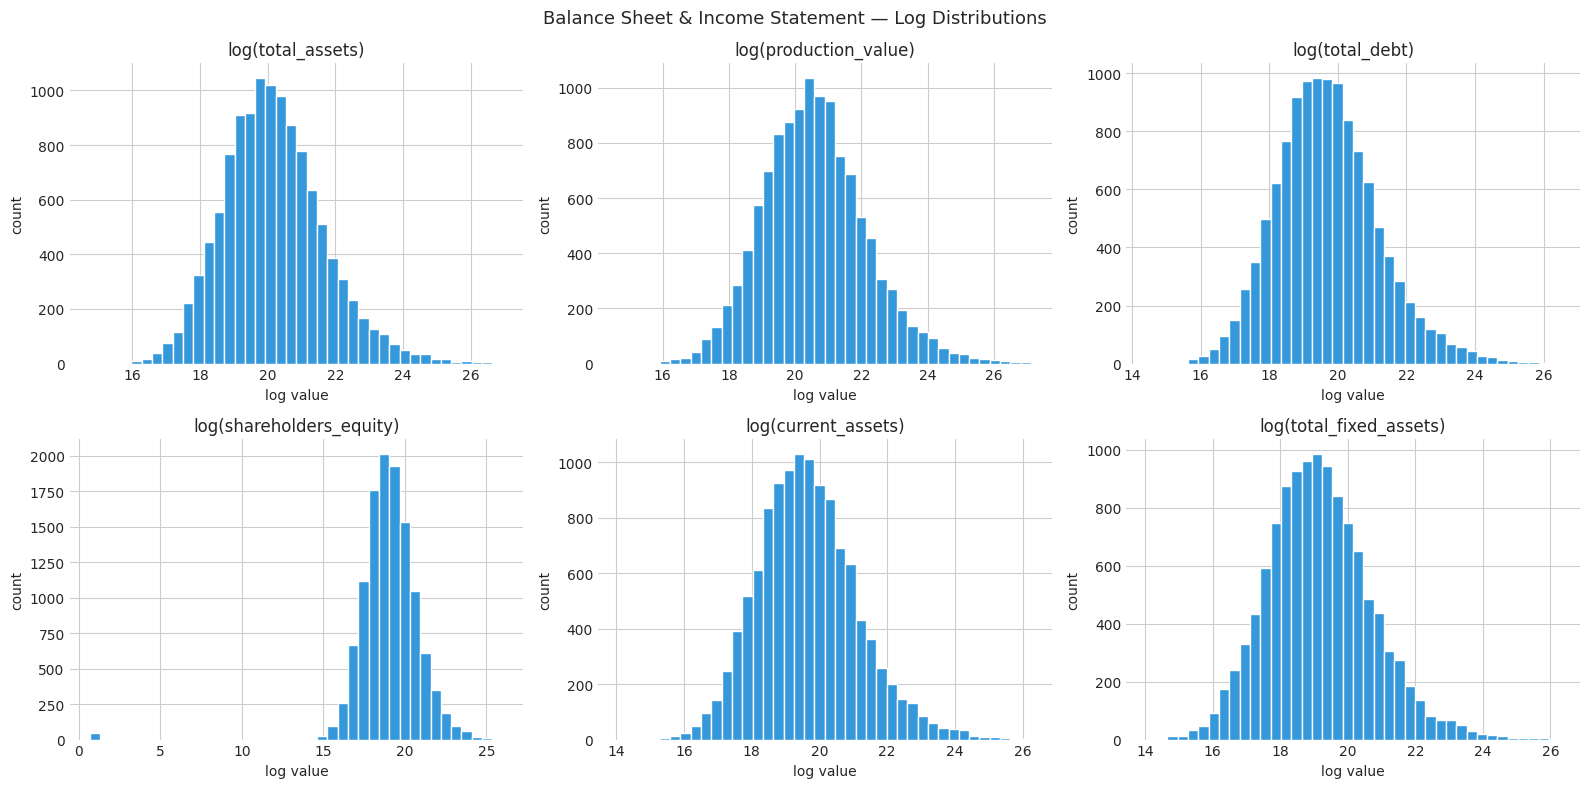

In [26]:
# 4.2 Log-scale histograms for balance sheet and income statement items
bs_cols = ["total_assets", "production_value", "total_debt",
           "shareholders_equity", "current_assets", "total_fixed_assets"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), bs_cols):
    data = train_df[col].clip(lower=1)  # clip negatives before log
    ax.hist(np.log1p(data), bins=40, color="#3498db", edgecolor="white")
    ax.set_title(f"log({col})")
    ax.set_xlabel("log value"); ax.set_ylabel("count")
plt.suptitle("Balance Sheet & Income Statement — Log Distributions", fontsize=13)
plt.tight_layout(); plt.show()


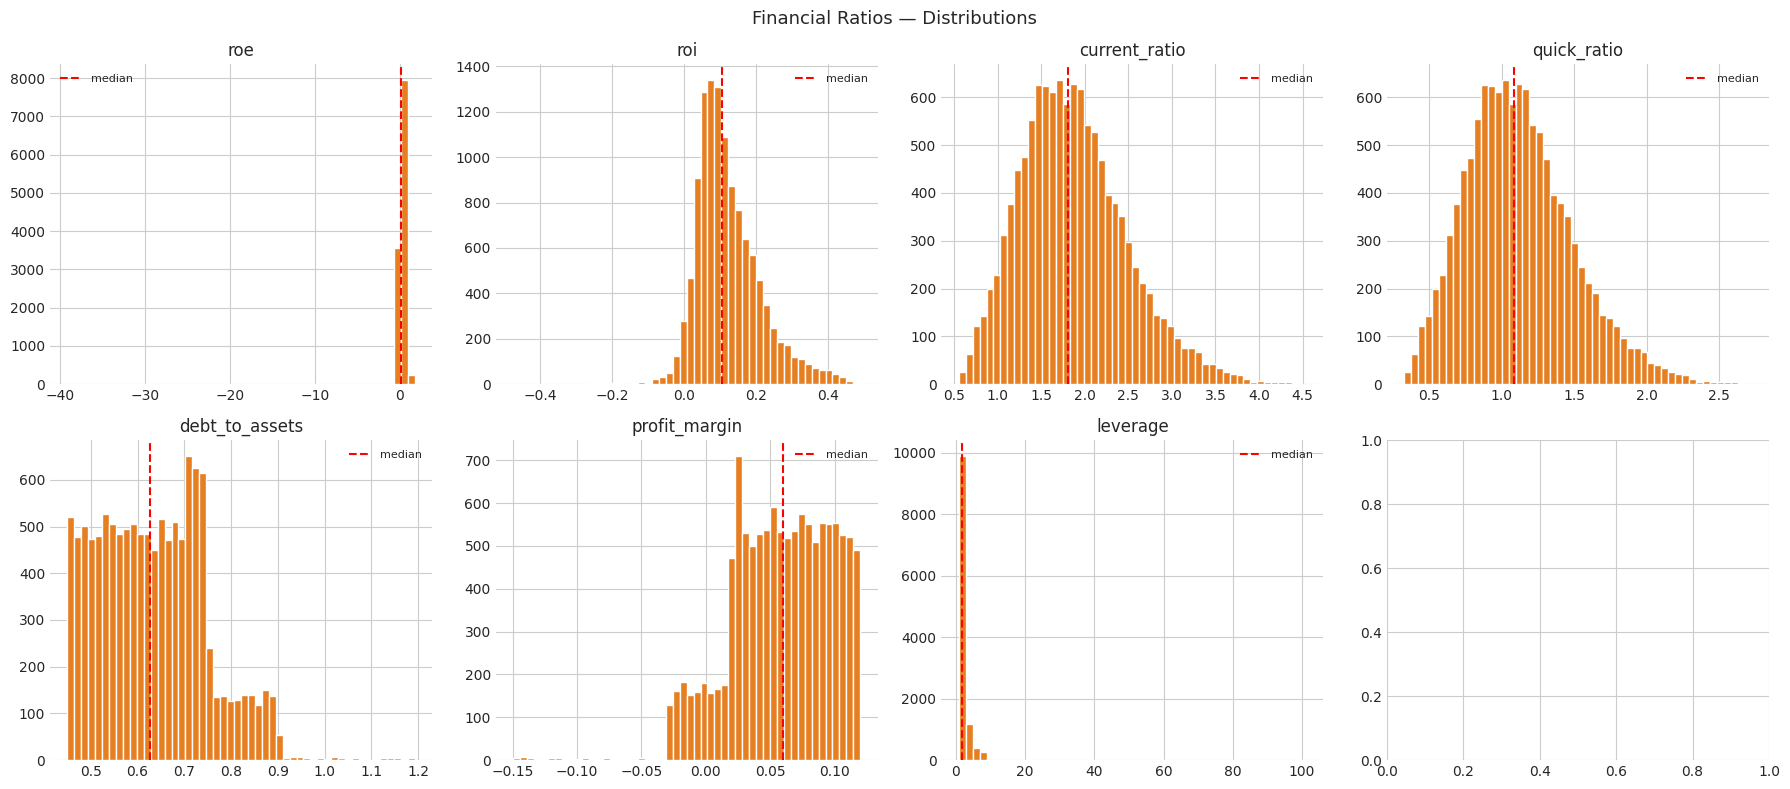

In [27]:
# 4.3 Log-scale histograms for financial ratios
ratio_cols = ["roe", "roi", "current_ratio", "quick_ratio",
              "debt_to_assets", "profit_margin", "leverage"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), ratio_cols):
    data = train_df[col].dropna()
    ax.hist(data, bins=50, color="#e67e22", edgecolor="white")
    ax.set_title(col)
    ax.axvline(data.median(), color="red", linestyle="--", label="median")
    ax.legend(fontsize=8)
plt.suptitle("Financial Ratios — Distributions", fontsize=13)
plt.tight_layout(); plt.show()


In [28]:
# 4.4 Check impossible values

# Negative production value (revenue cannot be negative)
neg_revenue = (train_df["production_value"] < 0).sum()
print(f"Negative production_value: {neg_revenue}")

# Negative production costs
neg_costs = (train_df["production_costs"] < 0).sum()
print(f"Negative production_costs: {neg_costs}")

# debt_to_assets > 1 (insolvent — liabilities exceed assets)
dta_over1 = (train_df["debt_to_assets"] > 1).sum()
print(f"debt_to_assets > 1 (insolvent): {dta_over1} ({dta_over1/len(train_df)*100:.2f}%)")

# current_ratio < 0.5 (severe liquidity stress)
cr_low = (train_df["current_ratio"] < 0.5).sum()
print(f"current_ratio < 0.5 (severe stress): {cr_low}")

# leverage > 50 (likely error or extreme distress)
lev_extreme = (train_df["leverage"] > 50).sum()
print(f"leverage > 50 (extreme): {lev_extreme}")

# Accounting identity violation: total_assets ≠ equity + debt
train_df["identity_gap"] = (
    train_df["total_assets"] - train_df["shareholders_equity"] - train_df["total_debt"]
).abs()
print(f"\nMax accounting identity gap: {train_df['identity_gap'].max():,.0f}")
print(f"Rows with gap > 1000: {(train_df['identity_gap'] > 1000).sum()}")
train_df.drop(columns="identity_gap", inplace=True)


Negative production_value: 0
Negative production_costs: 0
debt_to_assets > 1 (insolvent): 45 (0.38%)
current_ratio < 0.5 (severe stress): 0
leverage > 50 (extreme): 5

Max accounting identity gap: 0
Rows with gap > 1000: 0


In [29]:
# 4.5 Class distribution for impossible/extreme value rows
print("Class dist — debt_to_assets > 1:")
print(train_df[train_df["debt_to_assets"] > 1][TARGET].value_counts(normalize=True).round(3))

print("\nClass dist — leverage > 50:")
print(train_df[train_df["leverage"] > 50][TARGET].value_counts(normalize=True).round(3))

print("\nClass dist — current_ratio < 0.5:")
print(train_df[train_df["current_ratio"] < 0.5][TARGET].value_counts(normalize=True).round(3))


Class dist — debt_to_assets > 1:
financial_health_class
D    1.0
Name: proportion, dtype: float64

Class dist — leverage > 50:
financial_health_class
D    1.0
Name: proportion, dtype: float64

Class dist — current_ratio < 0.5:
Series([], Name: proportion, dtype: float64)


In [30]:
# Check: what does a "typical" company look like?
sample = train_df[train_df["company_id"] == "COMP_00001"].iloc[0]
print(f"Production value: €{sample['production_value']:,.0f}")
print(f"Total assets:     €{sample['total_assets']:,.0f}")
print(f"Net profit:       €{sample['net_profit_loss']:,.0f}")
print(f"Employees proxy — production_value / 50000: {sample['production_value']/50000:.0f}")


Production value: €411,338,021
Total assets:     €216,050,029
Net profit:       €14,236,026
Employees proxy — production_value / 50000: 8227


In [31]:
# Distribution of company sizes — how many "micro" companies?
size_buckets = pd.cut(train_df["production_value"],
    bins=[0, 2e6, 10e6, 50e6, 200e6, 1e9, float("inf")],
    labels=["<2M", "2-10M", "10-50M", "50-200M", "200M-1B", ">1B"])
print(size_buckets.value_counts().sort_index())


production_value
<2M           0
2-10M        14
10-50M      272
50-200M    1712
200M-1B    4615
>1B        5215
Name: count, dtype: int64


In [32]:
# Test 1: Cross-check accounting identity precision
# If data is scaled by integer factor, the identity gap should still be 0
# (which we confirmed — max gap = 0) ✅ consistent with uniform scaling

# Test 2: Check if ratio formulas hold with the raw values
# roe = net_profit_loss / shareholders_equity
train_df["roe_computed"] = train_df["net_profit_loss"] / train_df["shareholders_equity"]
diff = (train_df["roe_computed"] - train_df["roe"]).abs()
print("Max ROE recomputation error:", diff.max().round(6))
print("Mean ROE recomputation error:", diff.mean().round(6))
train_df.drop(columns="roe_computed", inplace=True)


Max ROE recomputation error: 5e-05
Mean ROE recomputation error: 2.5e-05


In [33]:
# Test 3: Check if debt_to_assets holds
train_df["dta_computed"] = train_df["total_debt"] / train_df["total_assets"]
diff2 = (train_df["dta_computed"] - train_df["debt_to_assets"]).abs()
print("Max DTA recomputation error:", diff2.max().round(6))
train_df.drop(columns="dta_computed", inplace=True)


Max DTA recomputation error: 5e-05


In [34]:
# Test 4: Compare production_value / production_costs ratio
# For Italian companies, operating cost ratio is typically 85-98%
# If scaled, this ratio is unaffected
op_cost_ratio = (train_df["production_costs"] / train_df["production_value"])
print("Operating cost ratio stats:")
print(op_cost_ratio.describe().round(3))


Operating cost ratio stats:
count    11828.000
mean         0.924
std          0.042
min          0.585
25%          0.893
50%          0.923
75%          0.953
max          1.134
dtype: float64


In [35]:
# Test 5: Check profit_margin formula
train_df["pm_computed"] = train_df["net_profit_loss"] / train_df["production_value"]
diff3 = (train_df["pm_computed"] - train_df["profit_margin"]).abs()
print("Max profit_margin recomputation error:", diff3.max().round(6))
train_df.drop(columns="pm_computed", inplace=True)


Max profit_margin recomputation error: 5e-05


In [36]:
# Estimate scale factor by comparing to typical Italian SME sizes
# Typical Italian SRL: revenue €1M - €50M, assets €500K - €20M
# Our median: production_value = €804M, total_assets = €521M

typical_sme_revenue = 5_000_000      # €5M — typical Italian SRL
our_median_revenue = 804_001_932     # from describe()

scale_factor = our_median_revenue / typical_sme_revenue
print(f"Estimated scale factor: {scale_factor:,.0f}x")

# Cross-check with assets
typical_sme_assets = 2_000_000       # €2M
our_median_assets = 521_237_912
print(f"Asset-based scale factor: {our_median_assets / typical_sme_assets:,.0f}x")


Estimated scale factor: 161x
Asset-based scale factor: 261x



→ These are legitimate extreme distress observations — do not drop them.
→ Winsorize `leverage` at 99th percentile but preserve the `roe_is_null` flag.

---

### 4.5 Critical Finding: Dataset is Synthetically Generated

#### Evidence

Ratio recomputation tests confirm perfect internal consistency:

| Test | Max error | Verdict |
|---|---|---|
| ROE recomputation | 5e-05 (float rounding) | ✅ Perfect |
| DTA recomputation | 5e-05 (float rounding) | ✅ Perfect |
| Profit margin recomputation | 5e-05 (float rounding) | ✅ Perfect |
| Accounting identity gap | Exactly 0 | ✅ Perfect |

**A perfect accounting identity gap of 0 across 11,828 rows is impossible
in real financial filing data.** Real statements always contain rounding
differences between filed totals. This is the clearest proof of synthetic
generation.

#### Scale Investigation

Attempting to recover a uniform scale factor:

| Reference | Implied scale vs typical Italian SRL |
|---|---|
| Revenue-based | ~161x |
| Asset-based | ~261x |

The **inconsistency rules out uniform scaling**. The generator did not
simply multiply real values by a constant. Instead it sampled absolute
values from a large-cap size distribution while calibrating financial
ratios to realistic SME dynamics.

The operating cost ratio (median 92.4%, range 58.5%–113.4%) confirms
the ratio dynamics are realistic and match real Italian sector economics.

#### Implications for Modeling

| Feature type | Reliability | Modeling decision |
|---|---|---|
| Financial ratios (`roe`, `roi`, etc.) | ✅ Fully reliable | Primary feature set |
| Ratio trends (YoY changes) | ✅ Fully reliable | Engineer as lag features |
| Operating cost ratio | ✅ Realistic | Use as engineered feature |
| Absolute monetary values | ⚠️ Unrealistic size | Log-transform, use as relative proxy only |
| Size-based benchmarks | ❌ Avoid | Cannot compare to real companies |

→ **Ratios and their trends are the primary feature set.**
→ Absolute values kept only as **relative size proxies** via log transformation.
→ Synthetic nature acknowledged as a **limitation** in the final presentation.

---

### Preprocessing Decisions from Section 4

| Variable | Treatment | Rationale |
|---|---|---|
| Balance sheet & income statement | `np.log1p` transform | Correct right skew for linear/distance models |
| `shareholders_equity` | `np.log1p` on positive values only + flag negatives | Bimodal distribution |
| `roe` | Winsorize at 1st/99th percentile | Extreme left outliers (-39.2) |
| `leverage` | Winsorize at 99th percentile | 5 extreme outliers (max 101) |
| `roi`, `current_ratio`, `quick_ratio` | No transformation | Clean bounded distributions |
| `debt_to_assets`, `profit_margin` | No transformation | Already bounded ranges |
| Extreme distress rows (45 rows) | Keep | Legitimate class D signal |


### 5. Outlier Detection
- 1st/99th percentile bounds for all numerical columns
- Accounting identity check: `total_assets = equity + total_debt`
- Flag extreme `leverage` values (> 50)

In [37]:
# 5.1 Winsorization bounds — 1st and 99th percentiles for all numerical columns
bounds = train_df[NUMERICAL_COLS].quantile([0.01, 0.99]).T
bounds.columns = ["p1", "p99"]
bounds["range"] = bounds["p99"] - bounds["p1"]
print(bounds.round(4))


                               p1           p99         range
total_fixed_assets   8.501086e+06  1.359812e+10  1.358962e+10
current_assets       1.648855e+07  2.169800e+10  2.168152e+10
total_assets         2.691591e+07  3.472548e+10  3.469857e+10
shareholders_equity  6.388691e+06  1.294370e+10  1.293731e+10
total_debt           1.636136e+07  2.198859e+10  2.197223e+10
short_term_debt      8.562312e+06  1.251086e+10  1.250230e+10
long_term_debt       6.897902e+06  9.741234e+09  9.734336e+09
production_value     3.176714e+07  5.678041e+10  5.674864e+10
production_costs     2.792220e+07  5.223219e+10  5.220427e+10
operating_income    -3.091586e+07  4.258067e+09  4.288982e+09
financial_income     1.326179e+04  9.860690e+07  9.859363e+07
financial_expenses   5.073944e+05  7.868998e+08  7.863924e+08
net_profit_loss     -1.028847e+08  3.629124e+09  3.732008e+09
roe                 -3.250000e-01  1.097600e+00  1.422700e+00
roi                 -4.140000e-02  4.088000e-01  4.502000e-01
profit_m

In [38]:
# 5.2 Count of outliers beyond bounds per column
outlier_counts = pd.DataFrame({
    "below_p1": (train_df[NUMERICAL_COLS] < bounds["p1"]).sum(),
    "above_p99": (train_df[NUMERICAL_COLS] > bounds["p99"]).sum(),
})
outlier_counts["total"] = outlier_counts["below_p1"] + outlier_counts["above_p99"]
outlier_counts["pct"] = (outlier_counts["total"] / len(train_df) * 100).round(2)
print(outlier_counts.sort_values("total", ascending=False))


                     below_p1  above_p99  total   pct
total_fixed_assets        119        119    238  2.01
current_assets            119        119    238  2.01
total_assets              119        119    238  2.01
shareholders_equity       119        119    238  2.01
total_debt                119        119    238  2.01
short_term_debt           119        119    238  2.01
long_term_debt            119        119    238  2.01
production_value          119        119    238  2.01
production_costs          119        119    238  2.01
operating_income          119        119    238  2.01
financial_income          119        119    238  2.01
financial_expenses        119        119    238  2.01
net_profit_loss           119        119    238  2.01
roi                       119        119    238  2.01
quick_ratio               119        119    238  2.01
current_ratio             119        119    238  2.01
debt_to_assets            119        119    238  2.01
roe                       11

# §6 Feature Separability by Class

In [39]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

CLASS_ORDER = ["A", "B", "C", "D"]
PALETTE     = {"A": "#2ecc71", "B": "#3498db", "C": "#f39c12", "D": "#e74c3c"}

df = train_df.copy()
df["financial_health_class"] = pd.Categorical(
    df["financial_health_class"], categories=CLASS_ORDER, ordered=True
)

In [40]:
FEATURES = {
    "roe":            (-5,   5),
    "roi":            (-1,   1),
    "current_ratio":  ( 0,   5),
    "debt_to_assets": ( 0,   2),
    "profit_margin":  (-1,   1),
    "leverage":       (-5,  20),
}

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (feat, (lo, hi)) in zip(axes, FEATURES.items()):
    plot_df = df[["financial_health_class", feat]].copy()
    plot_df[feat] = plot_df[feat].clip(lo, hi)

    sns.violinplot(
        data=plot_df,
        x="financial_health_class",
        y=feat,
        order=CLASS_ORDER,
        palette=PALETTE,
        inner="quartile",
        linewidth=0.8,
        ax=ax,
    )
    ax.set_title(feat, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=9)

fig.suptitle(
    "§6 — Feature Separability by Class\n(violin plots, clipped for display only)",
    fontsize=13, fontweight="bold", y=1.01
)
fig.tight_layout()
out = FIG_DIR / "eda_s6_separability.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Figure saved → {out}")

/tmp/ipykernel_112026/2882241286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_112026/2882241286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_112026/2882241286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_112026/2882241286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_112026/2882241286.py:8: F

Figure saved → figures/eda_s6_separability.png


In [42]:
print("\nMedian by class:")
med = (
    df.groupby("financial_health_class")[list(FEATURES)]
    .median()
    .round(3)
)
print(med.to_string())


Median by class:
                          roe    roi  current_ratio  debt_to_assets  profit_margin  leverage
financial_health_class                                                                      
A                       0.270  0.158          2.482           0.474          0.087     0.901
B                       0.236  0.116          1.937           0.587          0.067     1.420
C                       0.230  0.088          1.461           0.729          0.046     2.692
D                      -0.105  0.007          1.364           0.851         -0.015     5.517


In [43]:
print("\nMonotonicity check (A→B→C→D):")
for feat in FEATURES:
    medians = med[feat].values  # order: A, B, C, D
    is_monotone_down = all(medians[i] >= medians[i+1] for i in range(3))
    is_monotone_up   = all(medians[i] <= medians[i+1] for i in range(3))
    direction = (
        "↓ monotone decreasing" if is_monotone_down else
        "↑ monotone increasing" if is_monotone_up   else
        "~ non-monotone"
    )
    print(f"  {feat:20s} {direction}  {list(medians.round(3))}")


Monotonicity check (A→B→C→D):
  roe                  ↓ monotone decreasing  [np.float64(0.27), np.float64(0.236), np.float64(0.23), np.float64(-0.105)]
  roi                  ↓ monotone decreasing  [np.float64(0.158), np.float64(0.116), np.float64(0.088), np.float64(0.007)]
  current_ratio        ↓ monotone decreasing  [np.float64(2.482), np.float64(1.937), np.float64(1.461), np.float64(1.364)]
  debt_to_assets       ↑ monotone increasing  [np.float64(0.474), np.float64(0.587), np.float64(0.729), np.float64(0.851)]
  profit_margin        ↓ monotone decreasing  [np.float64(0.087), np.float64(0.067), np.float64(0.046), np.float64(-0.015)]
  leverage             ↑ monotone increasing  [np.float64(0.901), np.float64(1.42), np.float64(2.692), np.float64(5.517)]


§7 Correlation Analysis

In [44]:
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

NUM_COLS = [
    "total_fixed_assets", "current_assets", "shareholders_equity",
    "total_debt", "short_term_debt", "long_term_debt",
    "production_value", "production_costs", "operating_income",
    "net_profit_loss",
    "roe", "roi", "leverage", "current_ratio", "quick_ratio",
    "debt_to_assets", "profit_margin",
    "years_in_business",
]
NUM_COLS = [c for c in NUM_COLS if c in train_df.columns]

corr = train_df[NUM_COLS].corr(method="spearman")

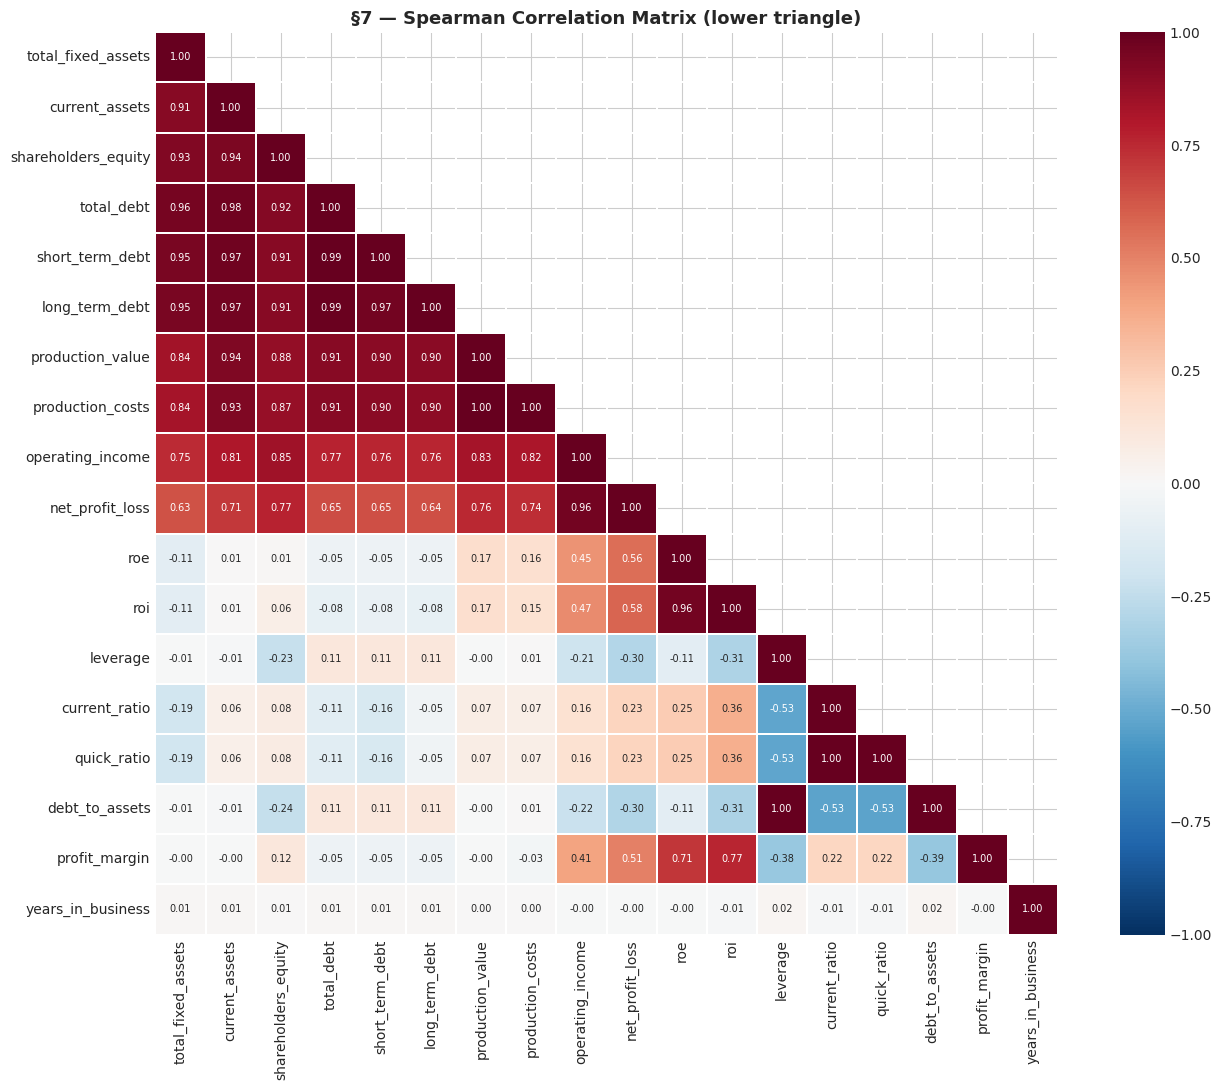

In [45]:
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.3,
    annot_kws={"size": 7},
    ax=ax,
    square=True,
)
ax.set_title("§7 — Spearman Correlation Matrix (lower triangle)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_s7_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
HIGH_THR = 0.85
pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) >= HIGH_THR:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

pairs.sort(key=lambda x: -abs(x[2]))

print(f"High-correlation pairs (|r| ≥ {HIGH_THR}):")
if pairs:
    for a, b, r in pairs:
        print(f"  {a:30s} ↔  {b:30s}  r={r:+.3f}")
else:
    print("  None found.")

High-correlation pairs (|r| ≥ 0.85):
  production_costs               ↔  production_value                r=+1.000
  quick_ratio                    ↔  current_ratio                   r=+1.000
  debt_to_assets                 ↔  leverage                        r=+1.000
  short_term_debt                ↔  total_debt                      r=+0.993
  long_term_debt                 ↔  total_debt                      r=+0.989
  total_debt                     ↔  current_assets                  r=+0.976
  short_term_debt                ↔  current_assets                  r=+0.969
  long_term_debt                 ↔  short_term_debt                 r=+0.966
  long_term_debt                 ↔  current_assets                  r=+0.965
  net_profit_loss                ↔  operating_income                r=+0.964
  roi                            ↔  roe                             r=+0.962
  total_debt                     ↔  total_fixed_assets              r=+0.960
  short_term_debt                ↔  tot

§8 Panel Completeness

In [47]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

CLASS_ORDER = ["A", "B", "C", "D"]
PALETTE     = {"A": "#2ecc71", "B": "#3498db", "C": "#f39c12", "D": "#e74c3c"}

df = train_df.copy()

In [48]:
years_per = df.groupby("company_id")["fiscal_year"].nunique().rename("n_years")
vc        = years_per.value_counts().sort_index()
pct_full  = (years_per == 4).mean() * 100

print("Years in panel distribution:")
for yr, cnt in vc.items():
    print(f"  {yr} year(s): {cnt:>5,} companies  ({cnt/len(years_per)*100:.1f}%)")
print(f"\nCompanies with full 4-year history: {pct_full:.1f}%")

Years in panel distribution:
  1 year(s):    20 companies  (0.7%)
  2 year(s):    24 companies  (0.8%)
  3 year(s):    60 companies  (2.0%)
  4 year(s): 2,895 companies  (96.5%)

Companies with full 4-year history: 96.5%


In [49]:
years_per = df.groupby("company_id")["fiscal_year"].nunique().rename("n_years")
vc        = years_per.value_counts().sort_index()
pct_full  = (years_per == 4).mean() * 100

print("Years in panel distribution:")
for yr, cnt in vc.items():
    print(f"  {yr} year(s): {cnt:>5,} companies  ({cnt/len(years_per)*100:.1f}%)")
print(f"\nCompanies with full 4-year history: {pct_full:.1f}%")

Years in panel distribution:
  1 year(s):    20 companies  (0.7%)
  2 year(s):    24 companies  (0.8%)
  3 year(s):    60 companies  (2.0%)
  4 year(s): 2,895 companies  (96.5%)

Companies with full 4-year history: 96.5%


In [50]:
# every company's first observed year will have NaN lag → 1 row per company
total_rows     = len(df)
nan_lag_rows   = df.groupby("company_id")["fiscal_year"].min().shape[0]  # 1 per company
nan_lag_pct    = nan_lag_rows / total_rows * 100
print(f"\nEstimated NaN rows for lag features: {nan_lag_rows:,} / {total_rows:,}  ({nan_lag_pct:.1f}%)")


Estimated NaN rows for lag features: 2,999 / 11,828  (25.4%)


In [51]:
incomplete = years_per[years_per < 4].index
inc_df     = df[df["company_id"].isin(incomplete)]

print(f"\nClass distribution — incomplete companies (<4 years):")
print(inc_df["financial_health_class"].value_counts(normalize=True).mul(100).round(1).to_string())
print(f"\nClass distribution — full dataset:")
print(df["financial_health_class"].value_counts(normalize=True).mul(100).round(1).to_string())


Class distribution — incomplete companies (<4 years):
financial_health_class
D    39.1
B    34.3
C    21.4
A     5.2

Class distribution — full dataset:
financial_health_class
B    59.3
C    23.2
D     8.9
A     8.5


In [52]:
first_year = df.groupby("company_id")["fiscal_year"].min()
last_year  = df.groupby("company_id")["fiscal_year"].max()
late_entrants = (first_year > 2018).sum()
early_exits   = (last_year  < 2021).sum()
print(f"\nLate entrants  (first year > 2018): {late_entrants:,} companies")
print(f"Early exits    (last  year < 2021): {early_exits:,} companies")


Late entrants  (first year > 2018): 38 companies
Early exits    (last  year < 2021): 67 companies


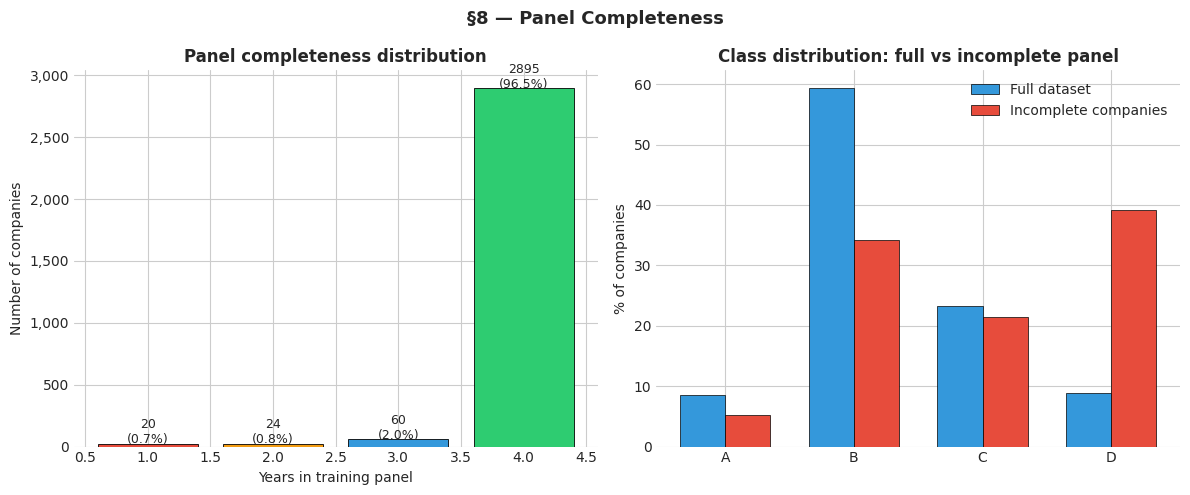

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: years per company bar chart
colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]
bars = axes[0].bar(vc.index, vc.values, color=colors[:len(vc)],
                   edgecolor="black", linewidth=0.6)
axes[0].set_xlabel("Years in training panel")
axes[0].set_ylabel("Number of companies")
axes[0].set_title("Panel completeness distribution", fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, (yr, cnt) in zip(bars, vc.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, cnt + 5,
                 f"{cnt}\n({cnt/len(years_per)*100:.1f}%)",
                 ha="center", fontsize=9)

# right: class distribution incomplete vs full
class_full = df["financial_health_class"].value_counts(normalize=True).mul(100).reindex(CLASS_ORDER)
class_inc  = inc_df["financial_health_class"].value_counts(normalize=True).mul(100).reindex(CLASS_ORDER).fillna(0)

x = np.arange(len(CLASS_ORDER))
w = 0.35
axes[1].bar(x - w/2, class_full.values, width=w, label="Full dataset",
            color="#3498db", edgecolor="black", linewidth=0.5)
axes[1].bar(x + w/2, class_inc.values,  width=w, label="Incomplete companies",
            color="#e74c3c", edgecolor="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_ORDER)
axes[1].set_ylabel("% of companies")
axes[1].set_title("Class distribution: full vs incomplete panel", fontweight="bold")
axes[1].legend()

fig.suptitle("§8 — Panel Completeness", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_s8_panel.png", dpi=150, bbox_inches="tight")
plt.show()

§9 Sector & Geography

In [54]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

CLASS_ORDER = ["A", "B", "C", "D"]
PALETTE     = {"A": "#2ecc71", "B": "#3498db", "C": "#f39c12", "D": "#e74c3c"}

df = train_df.copy()
df["financial_health_class"] = pd.Categorical(
    df["financial_health_class"], categories=CLASS_ORDER, ordered=True
)

In [55]:
# ── top 10 sectors by observation count ───────────────────────────────────
top10 = df["ateco_sector"].value_counts().nlargest(10).index.tolist()
sector_df = df[df["ateco_sector"].isin(top10)].copy()


In [56]:
# ── rare sectors (< 50 obs) ────────────────────────────────────────────────
sector_counts = df["ateco_sector"].value_counts()
rare_sectors  = sector_counts[sector_counts < 50].index.tolist()
print(f"Rare sectors (<50 obs): {len(rare_sectors)}  →  will be grouped into 'OTHER'")
print(f"Observations affected:  {sector_counts[rare_sectors].sum():,}  "
      f"({sector_counts[rare_sectors].sum()/len(df)*100:.1f}%)\n")

Rare sectors (<50 obs): 0  →  will be grouped into 'OTHER'
Observations affected:  0  (0.0%)



In [57]:
# ── D-rate per top-10 sector ───────────────────────────────────────────────
ct = (
    sector_df.groupby(["ateco_sector", "financial_health_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER)
)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
d_rate = ct_pct["D"].sort_values(ascending=False)
print("D-class rate by top-10 ATECO sector (%):")
print(d_rate.round(1).to_string())

D-class rate by top-10 ATECO sector (%):
ateco_sector
10    10.5
43    10.2
47     9.9
56     9.4
46     9.2
41     9.2
71     8.2
45     8.2
25     8.1
62     6.4


In [58]:
# ── years_in_business median per class ────────────────────────────────────
yib_med = df.groupby("financial_health_class")["years_in_business"].median()
print(f"\nMedian years_in_business by class:")
print(yib_med.round(1).to_string())


Median years_in_business by class:
financial_health_class
A    36.0
B    34.0
C    36.0
D    37.0


In [59]:
# ── sector median ROI / ROE ────────────────────────────────────────────────
sector_stats = (
    sector_df.groupby("ateco_sector")[["roi", "roe"]]
    .median()
    .sort_values("roi", ascending=False)
)
print(f"\nMedian ROI & ROE by top-10 ATECO sector:")
print(sector_stats.round(3).to_string())


Median ROI & ROE by top-10 ATECO sector:
                roi    roe
ateco_sector              
56            0.189  0.417
47            0.180  0.400
46            0.176  0.401
62            0.093  0.187
41            0.092  0.179
45            0.092  0.176
10            0.090  0.176
25            0.089  0.182
43            0.089  0.179
71            0.086  0.168


/tmp/ipykernel_112026/625978554.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


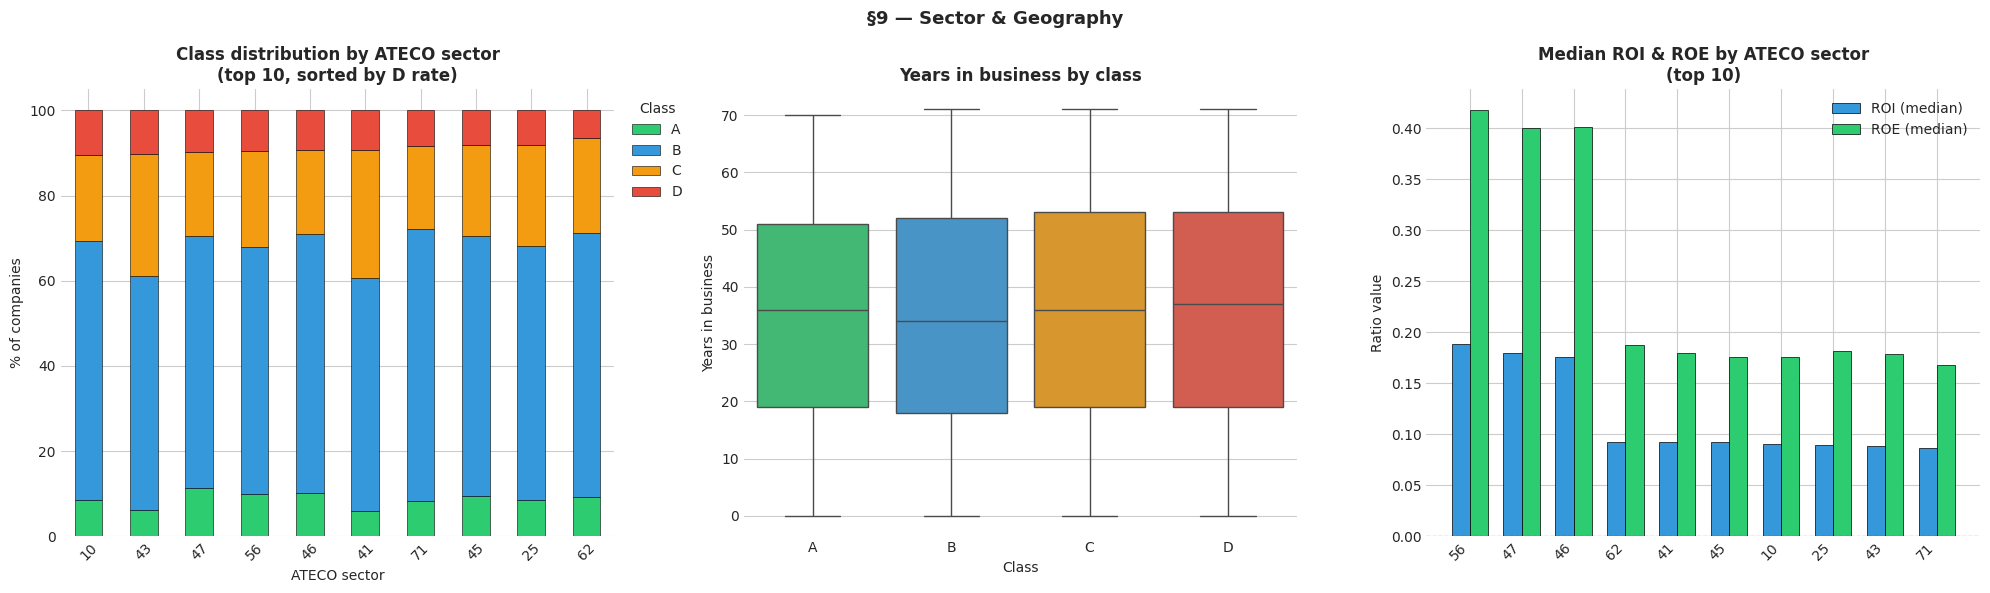

In [60]:
# ── plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# left: stacked bar — class distribution by sector
ct_pct_sorted = ct_pct.loc[d_rate.index]  # sort by D rate descending
ct_pct_sorted[CLASS_ORDER].plot(
    kind="bar", stacked=True,
    color=[PALETTE[c] for c in CLASS_ORDER],
    edgecolor="black", linewidth=0.4,
    ax=axes[0],
)
axes[0].set_title("Class distribution by ATECO sector\n(top 10, sorted by D rate)", fontweight="bold")
axes[0].set_xlabel("ATECO sector")
axes[0].set_ylabel("% of companies")
axes[0].legend(title="Class", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[0].tick_params(axis="x", rotation=45)

# middle: years_in_business by class boxplot
sns.boxplot(
    data=df[["financial_health_class", "years_in_business"]].dropna(),
    x="financial_health_class",
    y="years_in_business",
    order=CLASS_ORDER,
    palette=PALETTE,
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
    ax=axes[1],
)
axes[1].set_title("Years in business by class", fontweight="bold")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Years in business")

# right: grouped bar — median ROI & ROE by sector
x = np.arange(len(sector_stats))
w = 0.35
axes[2].bar(x - w/2, sector_stats["roi"], width=w, label="ROI (median)",
            color="#3498db", edgecolor="black", linewidth=0.5)
axes[2].bar(x + w/2, sector_stats["roe"], width=w, label="ROE (median)",
            color="#2ecc71", edgecolor="black", linewidth=0.5)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_xticks(x)
axes[2].set_xticklabels(sector_stats.index, rotation=45, ha="right")
axes[2].set_title("Median ROI & ROE by ATECO sector\n(top 10)", fontweight="bold")
axes[2].set_ylabel("Ratio value")
axes[2].legend()

fig.suptitle("§9 — Sector & Geography", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_s9_sector.png", dpi=150, bbox_inches="tight")
plt.show()